In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_excel('case_1_labeled_data.xlsx')
test = pd.read_excel('case_1_text_to_predict.xlsx')

In [3]:
train.head()

,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik


In [4]:
test.head()

,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo


## EDA

In [5]:
train['label'].value_counts()

label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64

#### Cek Duplikat

In [6]:
print(train.duplicated().sum())
print(train['full_text'].duplicated().sum())
print(test.duplicated().sum())

1
1
0


In [7]:
train = train.drop_duplicates()

print(train.duplicated().sum())

0


#### Panjang Token

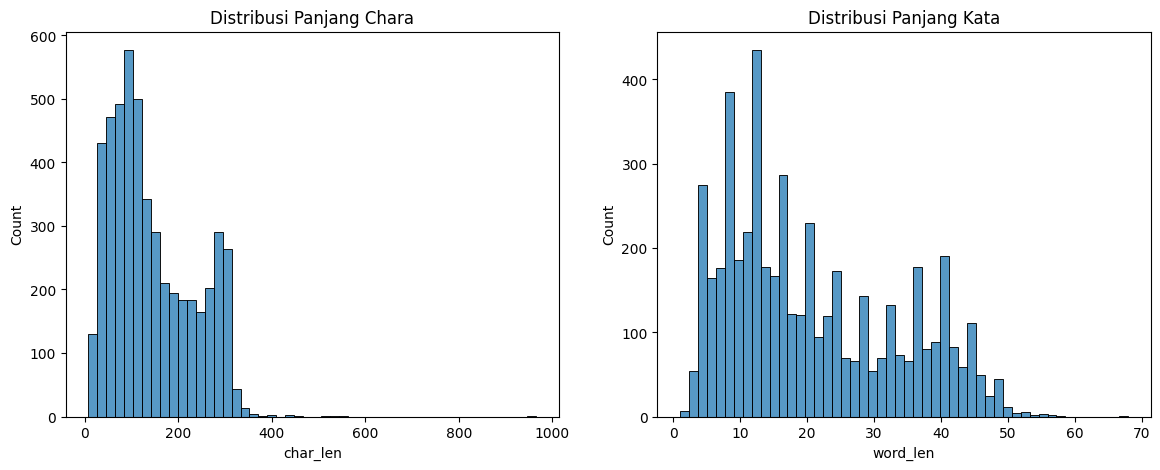

In [14]:
train['char_len'] = train['full_text'].apply(len)
train['word_len'] = train['full_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(train['char_len'],bins=50, ax=axes[0])
axes[0].set_title("Distribusi Panjang Chara")


sns.histplot(train['word_len'],bins=50, ax=axes[1])
axes[1].set_title("Distribusi Panjang Kata")

plt.show()

> Skew kanan banget, ini perlu key phrase(kata kunci) atau sesuatu yang bisa tambah representasinya

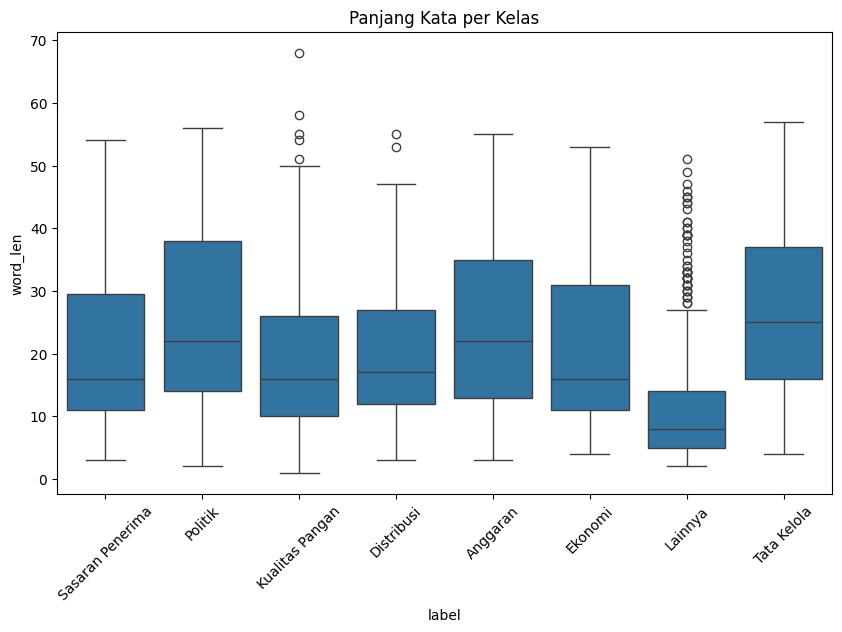

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(x='label', y='word_len', data=train)
plt.xticks(rotation=45)
plt.title('Panjang Kata per Kelas')
plt.show()

> Dari rata-ratanya, semua label punya sedikit kata apakagi kelas "_lainnya_" paling sedikit sama kelas ini juga paling sedikit jadi ada kemungkinan bakal ada model error dikelas yang ini.

#### Analisis N-Gram (Key Phrase

#### Analisis Emoji

#### Kemiripan Kelas (Class similarity)

## Preprocessing